---

MD004 - Algoritmos de Clustering (A: 8/01/2026) (B: 12/01/2026)

# Entrega 1 - Clustering

**Enunciado:** 

Una empresa de helados llamada ``La Vía Láctea`` quiere hacer una campaña de marketing para augmentar la cantidad de clientes. Para hacer esto ha contactado a un equipo de investigación de la prestigiosa universidad de Harvard. Pero no estaban disponibles... <br> Así que decidieron ponerse en contacto con LaSalle para pedir el estudio de mercado a los estudiantes del MUDS.

**Se os pide:** utiliza el dataset ``customer_data.csv`` para encontrar posibles agrupaciones de clientes y así saber cómo enfocar la campaña. Para hacer esto es necesario que se realicen los siguientes apartados:

1. EDA (2.5 p) <br>
    1.1 Variables numéricas (1.25 p) <br>
    1.2 Variables categóricas (1.25 p) <br>
2. Procesado inicial de los datos (1.5 p) <br>
    2.1 Correlaciones (0.75 p) <br>
    2.2 PCA (0.75 p) <br>
3. Clustering (5 p) <br>
    3.1 Agrupación jerárquica (1 p) <br>
    3.2 K-means (1 p) <br>
    3.3 DBSCAN (1 p) <br>
    3.4 Optics  (Opcional +0,5 p. extras) ->  El solamente se aplica si se tiene una nota superior a 5. <br>
4. Justificación decisiones (2 p) <br>
5. Conclusión (1 p) <br>

El equipo de marketing de ``La Vía Láctea´´ pide que como resultado se entregue un estudio (en formato Jupyter notebook) que <u>explique detalladamente los hallazgos encontrados durante el estudio y que plante una propuesta de estrategia para abordar la campaña.<u>

<br><br>


---



## 0. Imports y carga de datos

In [29]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import math

In [30]:
df = pd.read_csv('customer_data.csv', delimiter='\t')

In [31]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [33]:
print(df.isnull().sum())
print(f"Cantidad de nulos encontrados: {df['Income'].isnull().sum()}")

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
Cantidad de nulos encontrados: 24


##### Observaciones iniciales sobre los datos

Después de cargar el dataset y ejecutar `df.info()`, observamos los siguientes puntos a corregir en el EDA:

1.  **Valores Nulos:** Todas las columnas parecen estar completas excepto `Income`, que tiene solo 2216 valores no nulos i 24 nulos. Tendremos que imputarlos.
2.  **Tipos de datos incorrectos:**
    * `Dt_Customer` (Object): Se está leyendo una fecha como texto. Debemos convertirla a formato *datetime* para poder operar con ella.
    * Variables Booleanas (int64): Variables como `AcceptedCmp` o `Response` aparecen como números, pero lógicamente son categorías binarias (Sí/No). Las trataremos como variables categóricas en el análisis.
3.  **Ingeniería de variables:**
    * `Year_Birth`: Es más útil convertirla a `Age` para facilitar la interpretación en los gráficos.
    * `Dt_Customer`: Es más útil convertirla a `Antiguedad` por la misma razón que la anterior.

Eliminamos las columnas `Z_CostContact` y `Z_Revenue` porque no nos interesan.

In [34]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

---

## 1. EDA ``(2.5p)``

En este apartado se tienen que estudiar los datos mediante gráficas (scatterplot, barplot, violinplot, pairplot, etc.) y tests (shapiro-wilk, anova, etc.). Se tiene que comentar lo que se está analizando, descubriendo y que decisiones se van a tomar en consecuencia.

El estudio estadístico tiene dos partes:
1) Estudio de variables numéricas ``(1.25p)``
2) Estudio de variables categóricas ``(1.25p)``

#### **1.0 Limpieza, Ingeniería de Variables y Preparación**

Antes de iniciar el análisis exploratorio, realizamos una transformación integral del dataset para corregir formatos y generar nuevas métricas de negocio:

1. **Imputación de nulos:** Rellenamos los valores faltantes en `Income` con la **mediana** para evitar que los valores extremos (outliers) distorsionen el promedio.
2. **Formato de Fecha:** Convertimos la columna `Dt_Customer` a tipo `datetime` para poder operar con ella.
3. **Ingeniería de Variables (Tiempo):**
* Creamos la variable `Age` (Edad) a partir de `Year_Birth`.
* Creamos la variable `Antiguedad` (días como cliente) tomando como referencia el 1 de Enero de 2015.

4. **Ingeniería de Variables (Negocio):**
* **`Total_Spend` (Gasto Total):** Sumamos las 6 categorías de productos (Vino, Carne, Fruta, Pescado, Dulces, Oro) para tener una visión unificada del valor monetario del cliente.
* **`Children_Total` (Hijos en casa):** Unificamos `Kidhome` y `Teenhome` para analizar el impacto total de la carga familiar.
* **`Total_Accepted_Cmp` (Engagement):** Sumamos las 5 campañas anteriores más la última respuesta (`Response`). Esto genera un score de fidelidad (de 0 a 6) que mide qué tan reactivo es el cliente a nuestras acciones de marketing.

5. **Ajuste de Variables Categóricas:** Convertimos las variables binarias y de respuesta (0 y 1) a tipo categórico para facilitar la visualización en el EDA.

In [35]:
# --- 1. DEFINICIÓN DE GRUPOS DE ANÁLISIS ---

# Grupo A: Perfil Cliente
vars_num_perfil = ['Age', 'Income', 'Children_Total', 'Recency', 'Antiguedad']
# Nota: Corregido 'MaritalStatus' a 'Marital_Status' para coincidir con el dataset estándar
vars_cat_perfil = ['Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'Complain']

# Grupo B: Productos
vars_num_productos = ['Total_Spend', 'MntWines', 'MntFruits', 'MntMeatProducts',
                      'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Grupo C: Promociones (Comportamiento ante ofertas)
vars_num_promo = ['Total_Accepted_Cmp', 'NumDealsPurchases']
vars_cat_promo = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Grupo D: Canales (Puntos de contacto)
vars_num_canales = ['NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumWebVisitsMonth']


# --- 2. LIMPIEZA E INGENIERÍA DE VARIABLES ---

# Imputación de nulos
df['Income'] = df['Income'].fillna(df['Income'].median())

# Formato de fechas
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Ingeniería de Tiempo (Referencia 2015)
df['Age'] = 2015 - df['Year_Birth']
fecha_referencia = pd.to_datetime("2015-01-01")
df['Antiguedad'] = (fecha_referencia - df['Dt_Customer']).dt.days

# Ingeniería de Negocio: Gasto Total
df['Total_Spend'] = (df['MntWines'] + df['MntFruits'] +
                     df['MntMeatProducts'] + df['MntFishProducts'] +
                     df['MntSweetProducts'] + df['MntGoldProds'])

# Ingeniería de Negocio: Familia
df['Children_Total'] = df['Kidhome'] + df['Teenhome']

# Ingeniería de Negocio: Engagement (Score de campañas)
# Importante: Sumamos antes de convertir a categoría
df['Total_Accepted_Cmp'] = (df['AcceptedCmp1'].astype(int) +
                            df['AcceptedCmp2'].astype(int) +
                            df['AcceptedCmp3'].astype(int) +
                            df['AcceptedCmp4'].astype(int) +
                            df['AcceptedCmp5'].astype(int) +
                            df['Response'].astype(int))

# Conversión de binarias a categóricas (para visualización)
cols_binarias = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

for col in cols_binarias:
    df[col] = df[col].astype('category')

# --- 3. VERIFICACIÓN FINAL ---
print("Estructura final del dataset (con nuevas variables):")
df.info()

print("\nVista previa de las nuevas métricas:")
display(df[['ID', 'Income', 'Age', 'Total_Spend', 'Children_Total', 'Total_Accepted_Cmp']].head())

Estructura final del dataset (con nuevas variables):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   

,ID,Income,Age,Total_Spend,Children_Total,Total_Accepted_Cmp
0,5524,58138.0,58,1617,0,1
1,2174,46344.0,61,27,2,0
2,4141,71613.0,50,776,0,0
3,6182,26646.0,31,53,1,0
4,5324,58293.0,34,422,1,0


##### Preparamos las listas de variables por grupos

In [36]:
# Grupo A: Perfil Cliente
vars_num_perfil = ['Age', 'Income', 'Children_Total', 'Recency', 'Antiguedad']
vars_cat_perfil = ['Education', 'MaritalStatus', 'Kidhome', 'Teenhome', 'Complain']

# Grupo B: Productos
vars_num_productos = ['Total_Spend', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                  'MntSweetProducts', 'MntGoldProds']
# Grupo C: Promociones
vars_num_promo = ['Total_Accepted_Cmp', 'NumDealsPurchases']
vars_cat_promo = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Grupo D: Canales
vars_num_canales = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

#### 1.1 Estudio Variables Numéricas

In [48]:
print("Grupo A: PERFIL DEL CLIENTE")
display(df[vars_num_perfil].describe().T.round(2))

print("\nGrupo B: PRODUCTOS")
display(df[vars_num_productos].describe().T.round(2))

print("\nGrupo C: PROMOCIONES")
display(df[vars_num_promo].describe().T.round(2))

print("\nGrupo D: CANALES")
display(df[vars_num_canales].describe().T.round(2))

Grupo A: PERFIL DEL CLIENTE


,count,mean,std,min,25%,50%,75%,max
Age,2240.0,46.19,11.98,19.0,38.00,45.0,56.00,122.0
Income,2240.0,52237.98,25037.96,1730.0,35538.75,51381.5,68289.75,666666.0
Children_Total,2240.0,0.95,0.75,0.0,0.00,1.0,1.00,3.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
Antiguedad,2240.0,539.58,202.12,186.0,366.75,541.5,715.00,885.0



Grupo B: PRODUCTOS


,count,mean,std,min,25%,50%,75%,max
Total_Spend,2240.0,605.80,602.25,5.0,68.75,396.0,1045.50,2525.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.06,41.28,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.02,52.17,0.0,9.00,24.0,56.00,362.0



Grupo C: PROMOCIONES


,count,mean,std,min,25%,50%,75%,max
Total_Accepted_Cmp,2240.0,0.45,0.89,0.0,0.0,0.0,1.0,5.0
NumDealsPurchases,2240.0,2.33,1.93,0.0,1.0,2.0,3.0,15.0



Grupo D: CANALES


,count,mean,std,min,25%,50%,75%,max
NumWebPurchases,2240.0,4.08,2.78,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2240.0,2.66,2.92,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2240.0,5.79,3.25,0.0,3.0,5.0,8.0,13.0
NumWebVisitsMonth,2240.0,5.32,2.43,0.0,3.0,6.0,7.0,20.0


##### 1. Análisis del Grupo A: PERFIL (Detección de Errores)

Lo más importante aquí son los Outliers que hemos confirmado.
* Age: El valor máximo es 122 años.
* * Esto es casi seguro un error de entrada de datos (alguien nacido en 1893 o 1900). Es imposible que un cliente activo tenga esa edad.
* Income: El 75% de la gente gana hasta 68.289, pero el máximo es 666.666.
* * Este valor es sospechoso. Aunque fuera real, es tan extremo que aplastaría cualquier gráfico y distorsionará el algoritmo de clustering.
* Recency: La media (49.11) y la mediana (49.0) son idénticas. El rango va de 0 a 99. Esto indica una **distribución uniforme**: hay clientes que compraron ayer y clientes que hace 3 meses que no vienen, repartidos por igual.


##### **2. Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**

Aquí vemos claramente qué vende la empresa y cómo gastan los clientes:
* El Producto Estrella (Vino): `MntWines` tiene la media más alta (304) con diferencia. Es el negocio principal.
* El Segundo Motor (Carne): `MntMeatProducts` és el siguiente (167).
* Productos "Nicho": Fruta, Pescado, Dulces y Oro tienen medianas bajísimas (de 8 a 24). Significa que la mitad de los clientes apenas compran estos productos.
* Asimetría (Skewness): En todas las variables de gasto, la Media > Mediana (ej. Vinos: 304 vs 173).
* * Esto confirma una distribución asimétrica positiva. La mayoría de clientes gasta importes "bajos-medios", pero hay un grupo pequeño de "ballenas" (clientes VIP) que gastan muchísimo (fíjate en el max de vinos: 1493).


##### **3. Análisis del Grupo C: CANALES (¿Dónde compran?)**

Tienda Física vs Web:
* `NumStorePurchases` (Media 5.79) gana a `NumWebPurchases` (Media 4.08).
* * La gente sigue prefiriendo ir a la tienda, pero la web es un canal muy fuerte (40% de las compras aprox).
* Web Visits:
* * Hay más visitas a la web (5.32) que compras en la web (4.08). Es normal, mucha gente entra a mirar pero no compra.
* Catálogo: Es el canal menos relevante (Mediana = 2), aunque tiene un máximo de 28.

Antes de passar a los gráficos, vemos mas a profundo esos outliers:

In [38]:
print("Edades > 80 años")
edades_altas = df[df['Age'] > 80]['Age'].value_counts().sort_index()
print(edades_altas)

print("\nIngresos > 100.000")
ingresos_altos = df[df['Income'] > 100000]['Income'].sort_values(ascending=False).head(10)
print(f"Total de casos > 100k: {len(df[df['Income'] > 100000])}")

print("Top 10 ingresos más altos:")
print(ingresos_altos)

Edades > 80 años
Age
115    1
116    1
122    1
Name: count, dtype: int64

Ingresos > 100.000
Total de casos > 100k: 13
Top 10 ingresos más altos:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64


Procedemos a crear un dataset limpio, `df_clean` eliminando:
* `Edad`: Ponemos que maximo los clientes puedan tener 90 años.
* `Income`: Eliminamos ingresos superiores a los 200K.

In [39]:
indices_originales = df.index
df_clean = df[(df['Age'] < 90) & (df['Income'] < 200000)].copy()

print(f"Filas originales: {len(df)}")
print(f"Filas tras limpiar: {len(df_clean)}")

indices_eliminados = df.index.difference(df_clean.index)
df_eliminados = df.loc[indices_eliminados]

print(f"Hemos eliminado {len(df_eliminados)} clientes atípicos.")

print("\nFilas eliminadas:")
display(df_eliminados[['ID', 'Age', 'Income']])

Filas originales: 2240
Filas tras limpiar: 2236
Hemos eliminado 4 clientes atípicos.

Filas eliminadas:


,ID,Age,Income
192,7829,115,36640.0
239,11004,122,60182.0
339,1150,116,83532.0
2233,9432,38,666666.0


##### Análisis Visual y Estadístico Completo (Histogramas, Boxplots y Q-Q Plots)

Con el dataset `df_clean` ya depurado (tras eliminar los valores extremos en edad e ingresos), procedemos a realizar el estudio univariante definitivo. Para ello, hemos diseñado una función que genera un panel con tres perspectivas visuales y una tabla de métricas estadísticas robustas para cada variable.

**1. Panel Visual (3 Gráficos por variable):**
* **Histograma:** Nos permite observar la forma de la distribución (campana, uniforme, sesgada...) y ubicar la tendencia central mediante una línea roja discontinua (Media).
* **Boxplot (Diagrama de Caja):** Fundamental para visualizar la dispersión y confirmar visualmente los *outliers* restantes.
* **Q-Q Plot (Gráfico Cuantil-Cuantil):** Es la prueba visual definitiva de normalidad. Compara la distribución de nuestros datos (puntos) contra una distribución normal teórica (línea roja). Si los puntos se ajustan a la recta, podemos asumir normalidad aunque los tests matemáticos sean estrictos.

**2. Validación Estadística (Tabla Resumen):**
* **Test de Shapiro-Wilk:** Test matemático de normalidad (relevante para selección de modelos, aunque sensible al tamaño de la muestra).
* **Métricas de Forma (Skewness y Curtosis):**
* *Asimetría (Skewness):* Cuantifica el sesgo hacia la izquierda o derecha.
* *Curtosis:* Indica si la distribución es muy "picuda" o tiene colas pesadas (frecuencia de valores extremos).
* **Desviación Estándar (Std):** Para cuantificar cuánto varían los datos respecto al promedio.

In [40]:
def analizar_grupo(nombre_grupo, lista_vars, df):
    """
    Función para generar Histogramas, Boxplots, Q-Q Plots y tabla estadística
    para un grupo de variables dado.
    """

    vars_por_fila = 2
    n_cols = 6
    n_rows = math.ceil(len(lista_vars) / vars_por_fila)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 3.5 * n_rows))
    fig.suptitle(f"Análisis: {nombre_grupo}", fontsize=18, fontweight='bold', y=1.02)

    axes_flat = axes.flatten() if n_rows > 1 else axes
    stats_resultados = []

    for i, col in enumerate(lista_vars):
        pos_base = i * 3

        ax_hist = axes_flat[pos_base]
        sns.histplot(data=df, x=col, ax=ax_hist, kde=True,
                     color='#3498db', edgecolor="black", linewidth=1)
        media = df[col].mean()
        ax_hist.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
        ax_hist.set_title(f"Dist: {col}", fontsize=10, fontweight='bold')
        ax_hist.set_xlabel("")
        ax_hist.tick_params(labelsize=8)
        ax_hist.legend(fontsize='x-small')

        ax_box = axes_flat[pos_base + 1]
        sns.boxplot(data=df, x=col, ax=ax_box, color='#e74c3c', width=0.5)
        ax_box.set_title("Outliers", fontsize=10, color='gray')
        ax_box.set_xlabel("")
        ax_box.tick_params(labelsize=8)

        ax_qq = axes_flat[pos_base + 2]
        (osm, osr), (slope, intercept, r) = stats.probplot(df[col], dist="norm", plot=ax_qq)
        ax_qq.get_lines()[0].set_markerfacecolor('#2ecc71')
        ax_qq.get_lines()[0].set_markeredgecolor('#27ae60')
        ax_qq.get_lines()[0].set_markersize(3)
        ax_qq.get_lines()[1].set_color('#c0392b')
        ax_qq.set_title(f"Q-Q Plot (R²={r**2:.2f})", fontsize=10)
        ax_qq.set_xlabel("Teórico", fontsize=8)
        ax_qq.set_ylabel("Real", fontsize=8)
        ax_qq.tick_params(labelsize=8)

        stat, p_value = stats.shapiro(df[col])
        skew = df[col].skew()
        kurt = df[col].kurt()
        mediana = df[col].median()
        std_dev = df[col].std()

        stats_resultados.append({
            "Variable": col,
            "Media": round(media, 2),
            "Mediana": round(mediana, 2),
            "Std": round(std_dev, 2),
            "Skew": round(skew, 2),
            "Kurt": round(kurt, 2),
            "Shapiro p": f"{p_value:.1e}",
        })

    total_slots = n_rows * n_cols
    vars_dibujadas = len(lista_vars) * 3
    for j in range(vars_dibujadas, total_slots):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Resumen Estadístico - {nombre_grupo}")
    df_stats = pd.DataFrame(stats_resultados)
    display(df_stats)

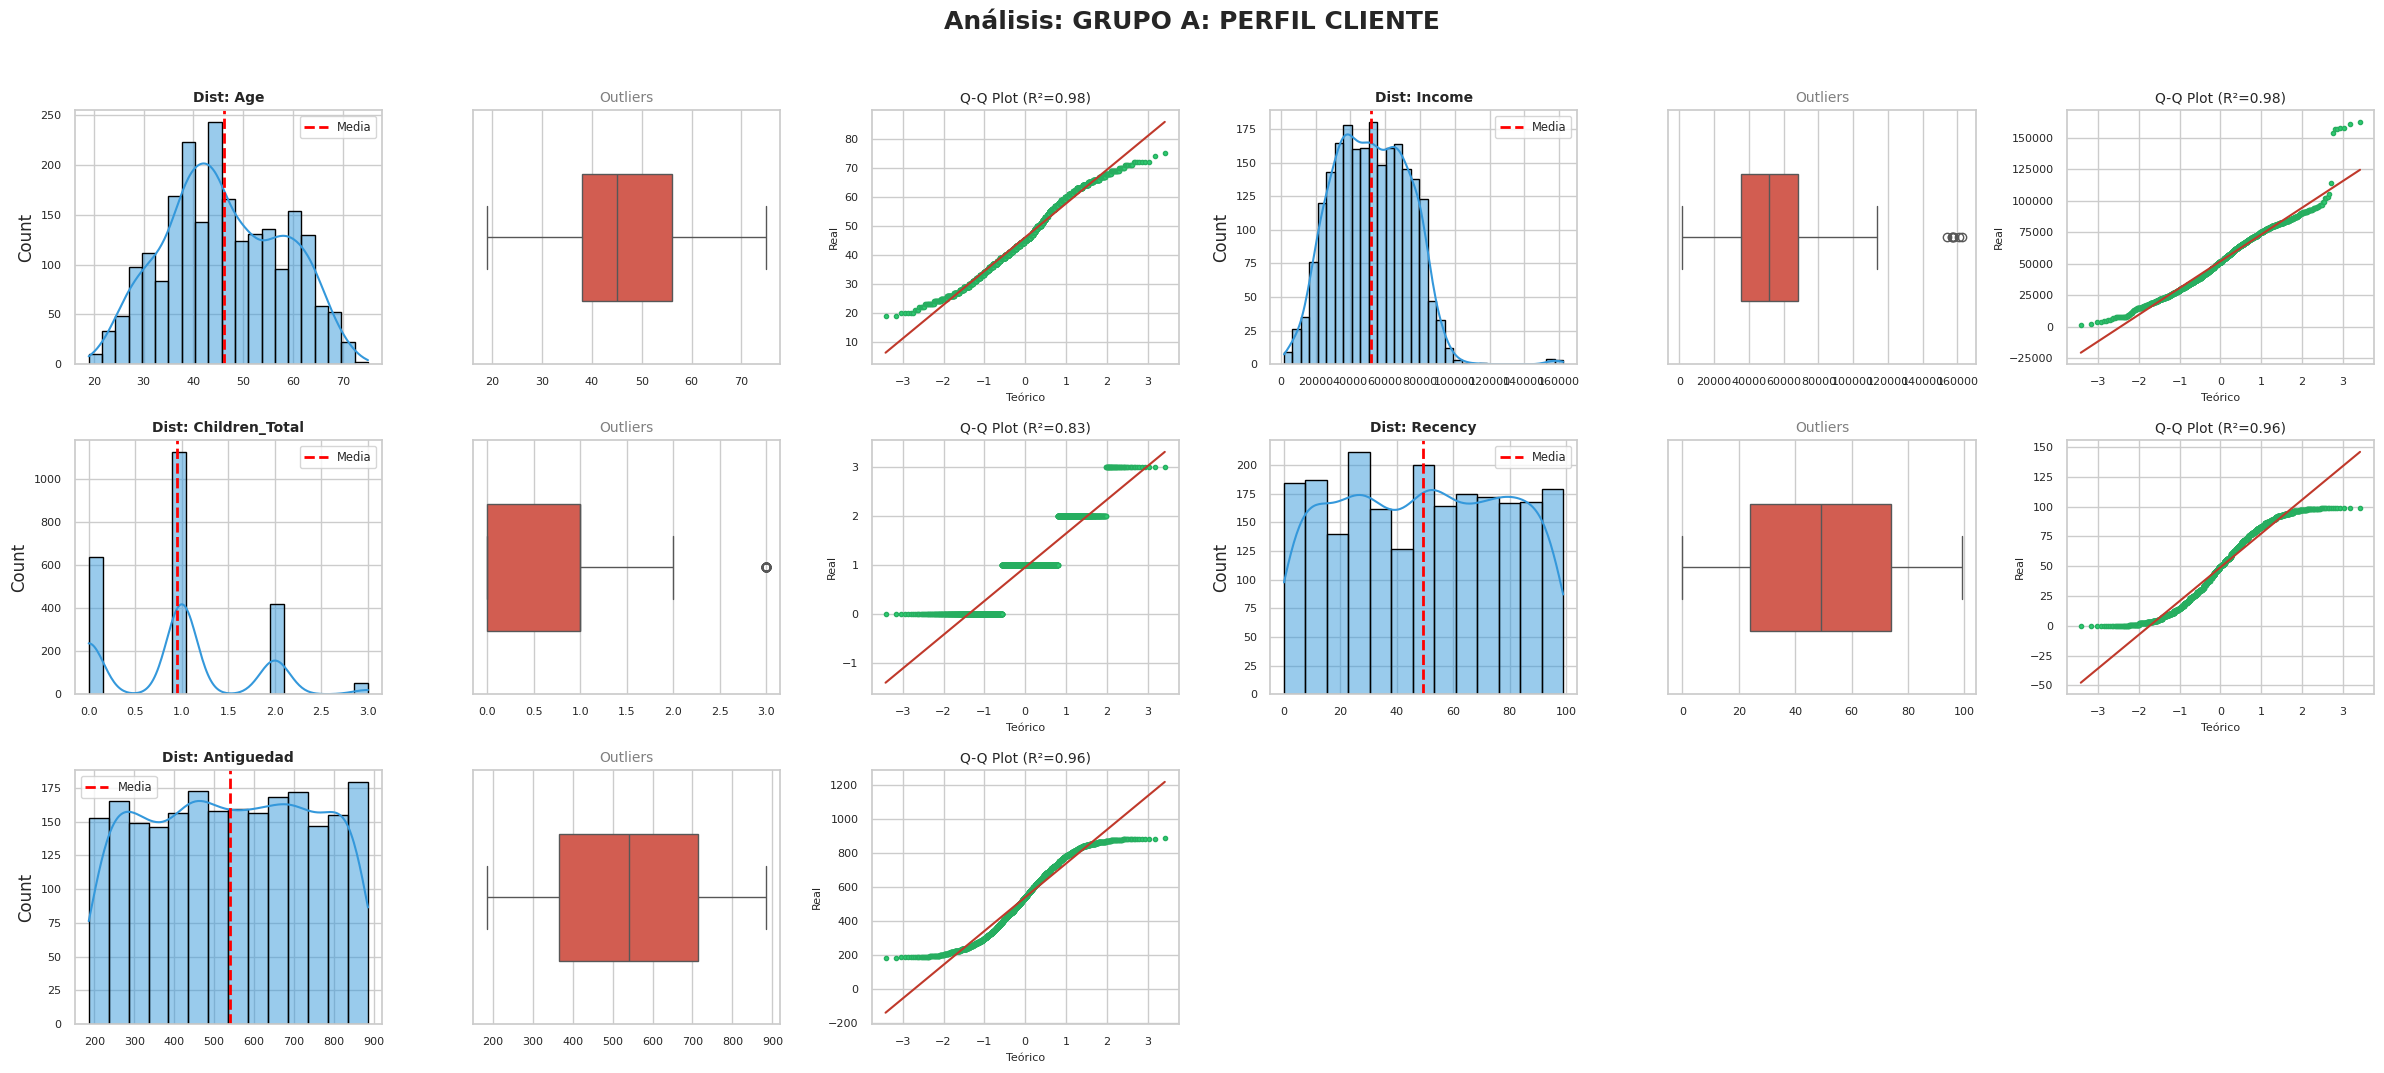

Resumen Estadístico - GRUPO A: PERFIL CLIENTE


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Age,46.10,45.0,11.70,0.09,-0.80,1.7e-15
1,Income,51952.61,51381.5,21411.47,0.35,0.76,6.2e-19
2,Children_Total,0.95,1.0,0.75,0.42,-0.25,1.1e-43
3,Recency,49.12,49.0,28.96,-0.00,-1.20,5.9e-26
4,Antiguedad,539.77,542.0,202.18,-0.02,-1.20,7.7e-26


In [41]:
analizar_grupo("GRUPO A: PERFIL CLIENTE", vars_num_perfil, df_clean)

#### **Análisis del Grupo A: PERFIL CLIENTE**

Tras la inspección visual y estadística, identificamos dos patrones claros de comportamiento:

1. **Variables Normales (`Age` e `Income`):**
* Ambas presentan una simetría robusta (`Skewness` < 0.5) y un ajuste visual casi perfecto a la normalidad en el Q-Q Plot ().
* *Nota sobre Income:* La leve cola superior es natural en salarios; el bajo skewness (0.35) confirma que la limpieza de outliers (>200k) fue exitosa.

2. **Variables Uniformes (`Recency` y `Antiguedad`):**
* Se caracterizan por histogramas planos y una **curtosis negativa** (). Esto indica una frecuencia constante de visitas y altas, sin estacionalidad ni picos anómalos.

**Conclusiones y Decisiones:**
* **Falso Positivo de Shapiro:** Debido al tamaño de la muestra (), ignoramos el p-value de Shapiro (demasiado estricto) y aceptamos la normalidad de *Age* e *Income* basándonos en la evidencia visual y los coeficientes de forma.
* **Escalado Obligatorio:** Dada la disparidad de magnitudes (Edad  46 vs Ingresos  52k), se aplicará **`StandardScaler`** antes de la fase de modelado (Clustering) para evitar sesgos por escala.

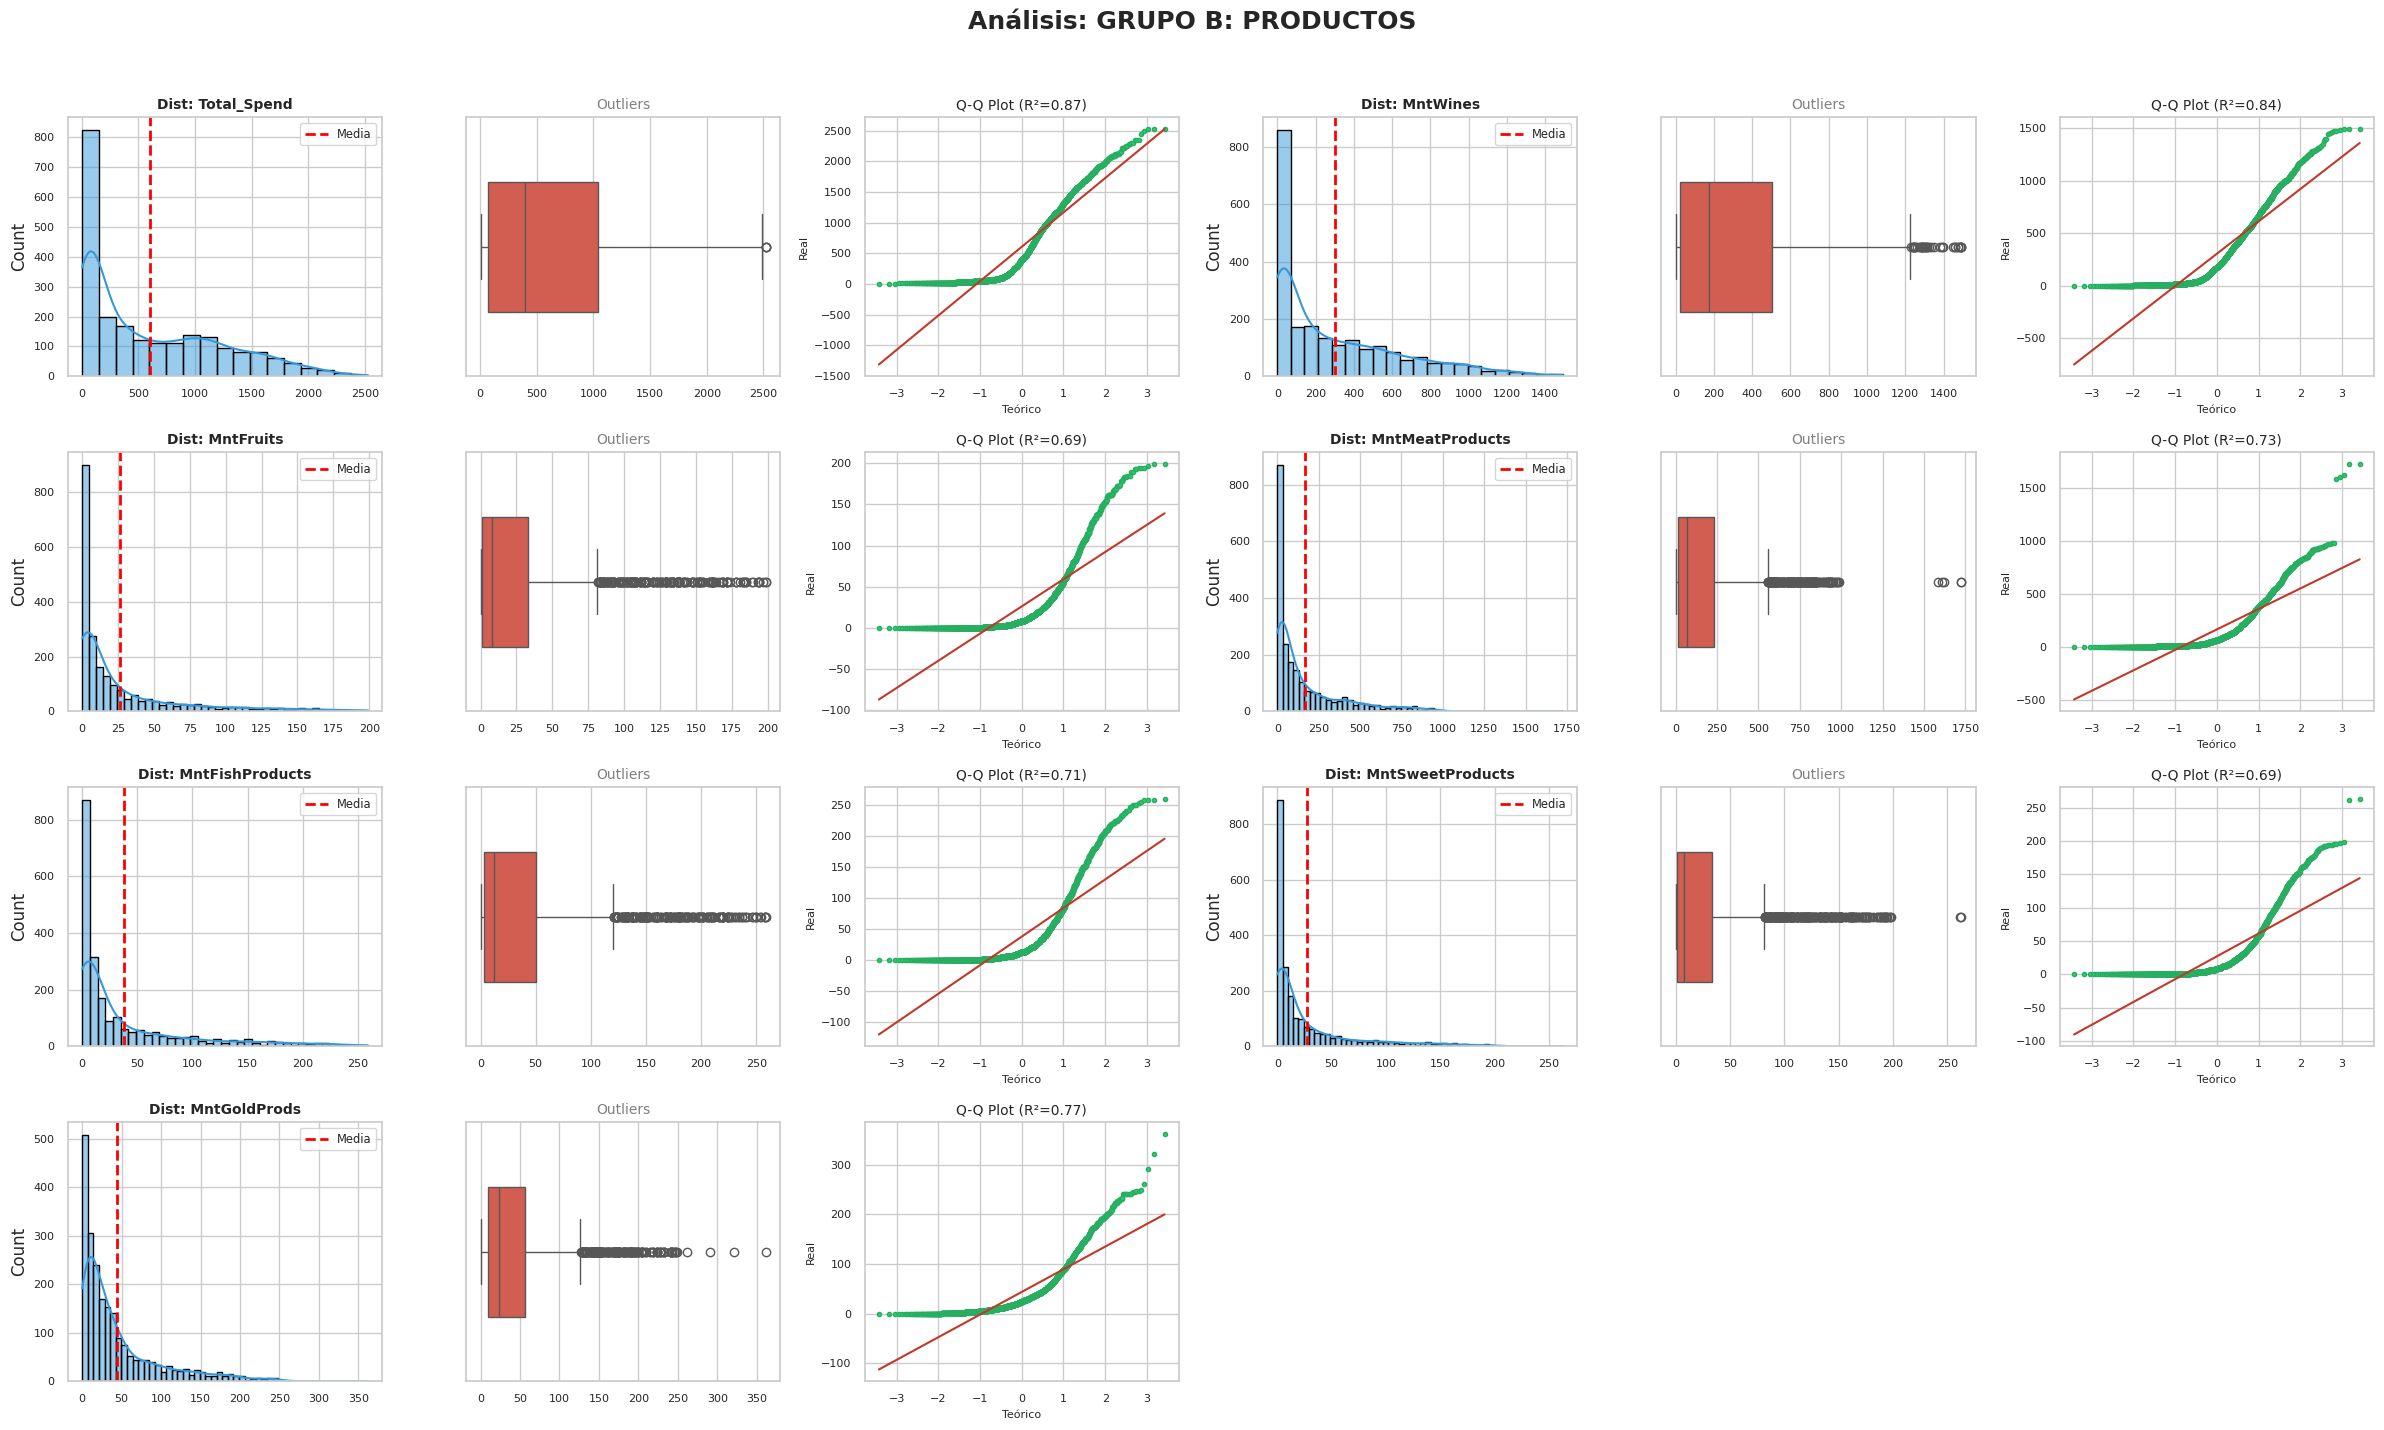

Resumen Estadístico - GRUPO B: PRODUCTOS


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Total_Spend,605.99,396.5,601.87,0.86,-0.34,3.3e-40
1,MntWines,304.13,174.0,336.59,1.18,0.60,6.4e-43
2,MntFruits,26.28,8.0,39.72,2.10,4.07,1.7e-53
3,MntMeatProducts,166.98,67.0,225.69,2.09,5.53,4.0e-51
4,MntFishProducts,37.54,12.0,54.65,1.92,3.10,2.1e-52
5,MntSweetProducts,27.08,8.0,41.30,2.14,4.37,1.2e-53
6,MntGoldProds,43.98,24.0,52.06,1.89,3.56,1.2e-48


In [42]:
analizar_grupo("GRUPO B: PRODUCTOS", vars_num_productos, df_clean)

#### **Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**

A diferencia de las variables demográficas, las variables de consumo (`MntWines`, `MntMeat`, etc.) muestran un patrón sistemático de **Asimetría Positiva Extrema**. No estamos ante una campana de Gauss, sino ante una distribución de "ley de potencia" (pareto), típica en datos transaccionales.

**1. Diagnóstico Visual (La "Banana" y los Outliers):**

* **Histogramas:** Todos tienen forma de "tobogán". La inmensa mayoría de las observaciones se acumulan a la izquierda (gasto bajo o nulo), con una cola muy larga hacia la derecha.
* **Q-Q Plots (Forma de Banana):** Fíjate en la curva convexa tan pronunciada (puntos verdes). Se alejan totalmente de la línea roja desde el principio. Los  bajan drásticamente (0.69 - 0.84). Esto es la **prueba visual irrefutable de la No-Normalidad**.
* **Boxplots:** Las "cajas" están aplastadas contra el cero y vemos una nube densa de puntos negros a la derecha. **Importante:** En este contexto, **estos outliers NO son ruido ni errores**; son los **Clientes VIP** (High-Value Customers) que sostienen la facturación de la empresa.

**2. Análisis de Métricas Clave:**
* **Disparidad Media vs. Mediana:**
* En todas las categorías, la **Media es muy superior a la Mediana**.
* *Ejemplo Vinos (`MntWines`):* El promedio es **304**, pero el 50% de los clientes gasta menos de **174**.
* *Ejemplo Fruta (`MntFruits`):* El promedio es **26**, pero la mediana es solo **8**.
* *Interpretación:* Unos pocos clientes que gastan mucho "inflan" el promedio. El cliente "típico" gasta poco en frescos y dulces, concentrando su presupuesto en **Vino y Carne**.
* **Asimetría (Skewness) y Curtosis:**
* **Skewness > 1.0 (e incluso > 2.0):** Confirma el sesgo extremo a la derecha.
* **Curtosis Elevada (Leptocurtosis):** Fíjate en `MntMeatProducts` (Curtosis = 5.53) o `MntSweet` (4.37). Valores tan altos indican "colas muy pesadas". Hay una probabilidad de encontrar gastos extremos mucho mayor de lo que habría en una distribución normal.

**3. Conclusiones y Decisiones de Modelado:**
1. **Rechazo Total de Normalidad:** Los p-values de Shapiro () confirman lo que vemos: estas variables no son normales bajo ningún estándar.
2. **Jerarquía de Productos:** Los datos revelan que el negocio se sostiene sobre dos pilares: **Vinos y Carnes** (tienen las medianas y rangos más altos). El resto (Fruta, Pescado, Oro) son compras de nicho o complementarias.
3. **Tratamiento Obligatorio:**
* Para algoritmos sensibles a la distancia (K-Means, KNN), estas variables **romperán el modelo** si se usan tal cual, ya que los VIPs dominarán los clústeres.
* **Acción:** Será necesario aplicar una transformación para "comprimir" estas colas, como la **Transformación Logarítmica (`np.log1p`)** o la **Transformación Box-Cox**, antes de escalar los datos.

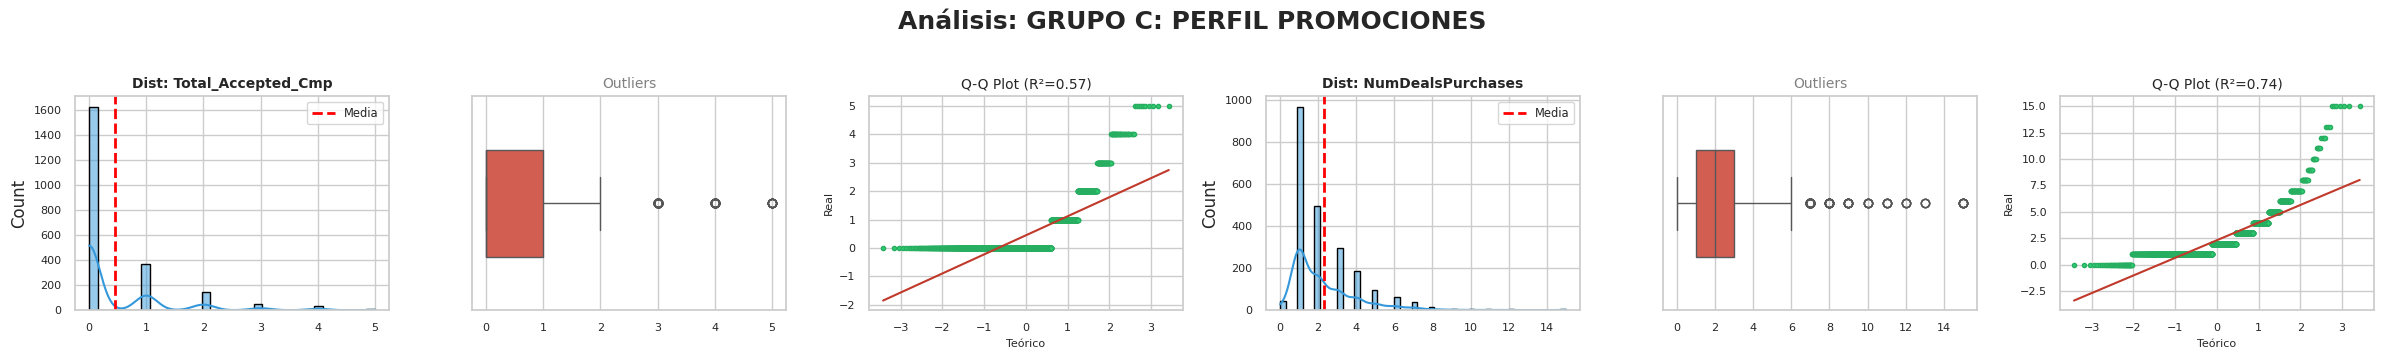

Resumen Estadístico - GRUPO C: PERFIL PROMOCIONES


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Total_Accepted_Cmp,0.45,0.0,0.89,2.44,6.33,2.5e-59
1,NumDealsPurchases,2.33,2.0,1.93,2.42,8.93,1.7e-50


In [49]:
analizar_grupo("GRUPO C: PERFIL PROMOCIONES", vars_num_promo, df_clean)

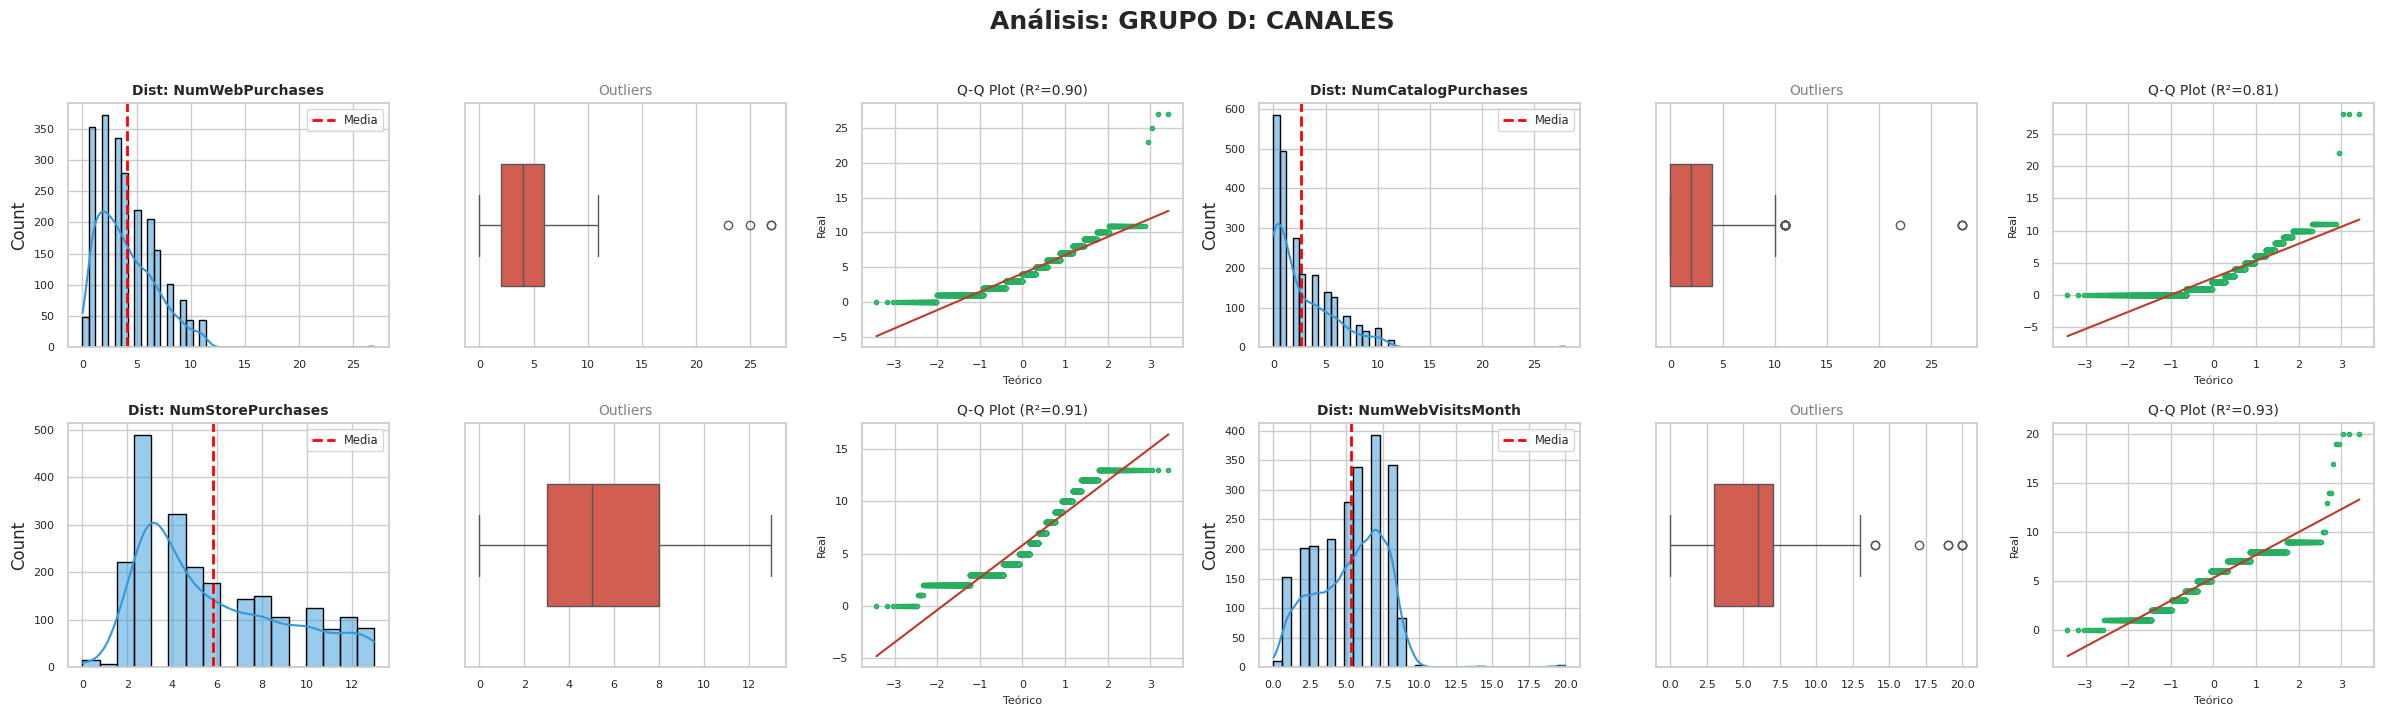

Resumen Estadístico - GRUPO D: CANALES


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,NumWebPurchases,4.09,4.0,2.78,1.38,5.70,3.4e-36
1,NumCatalogPurchases,2.66,2.0,2.92,1.88,8.05,5.2e-45
2,NumStorePurchases,5.80,5.0,3.25,0.70,-0.62,3.0e-35
3,NumWebVisitsMonth,5.32,6.0,2.43,0.21,1.82,3.6e-31


In [43]:
# Ejecutamos el análisis solo para el Grupo D
analizar_grupo("GRUPO D: CANALES", vars_num_canales, df_clean)

#### **Análisis del Grupo D: CANALES (Comportamiento de Compra)**

En este grupo analizamos la frecuencia de uso de los distintos puntos de contacto. Los datos presentan un comportamiento híbrido entre la normalidad y la "ley de potencia" que vimos en los productos.

**1. Tienda Física vs. Digital (La Batalla de los Canales):**
* **`NumStorePurchases` (La Reina):**
* Es el canal dominante con la media más alta (**5.80** compras).
* **Visualmente:** Es la distribución más "aplanada" (Kurtosis negativa de -0.62). Esto significa que el uso de la tienda física es muy generalizado; no hay un pico extremo, sino que una gran variedad de clientes compra entre 3 y 8 veces.
* **Skewness (0.70):** Es moderado. Aunque no es normal, es la variable de compra más equilibrada.
* **`NumWebPurchases` (El Aspirante):**
* Media de **4.09**. Tiene una forma más "picuda" y sesgada (Skew 1.38) que la tienda. Hay un grupo sólido de compradores online, pero también una cola de gente que compra muchísimo por la web (outliers superiores).

**2. Canales de Nicho (Catálogo y Ofertas):**
* **`NumCatalogPurchases` y `NumDealsPurchases`:**
* **Comportamiento de Nicho:** Ambas tienen **medias bajas** (~2.3 - 2.6) pero **Kurtosis altísimas** (8.05 y 8.93 respectivamente).
* **Interpretación:** La inmensa mayoría de clientes apenas usa estos canales (barras altas en 0, 1 o 2). Sin embargo, la curtosis extrema nos avisa de que existen "Heavy Users" (cazadores de ofertas o amantes del catálogo) que los usan masivamente (outliers en 10-15 compras).
* **Q-Q Plots:** Muestran una desviación extrema en las colas, confirmando que el comportamiento de "cazar ofertas" no es típico ni normal.

**3. Visitas Web (`NumWebVisitsMonth`):**
* **La "Casi Normal" del grupo:**
* Junto con la Edad, esta variable es la que mejor se comporta.
* **Skewness (0.21):** ¡Excelente! Es casi simétrica. La media (5.3) y mediana (6.0) están cerca.
* **Q-Q Plot:** Se ajusta muy bien a la línea roja, salvo por el hecho de ser escalonada (son números enteros).
* **Conclusión:** La gente visita la web de forma bastante predecible y regular, independientemente de si acaban comprando mucho o poco.

**Observación Técnica Importante (Los "Escalones"):**
Si te fijas en los Q-Q Plots (especialmente en *WebVisits* o *StorePurchases*), verás que los puntos verdes forman **escaleras**.
* **¿Por qué?** Porque son variables **discretas** (números enteros). No puedes hacer "3.5 visitas".
* **Impacto:** Esto hace que el test de Shapiro falle siempre, pero visualmente, `NumWebVisitsMonth` y `NumStorePurchases` son lo suficientemente robustas para trabajar sin transformaciones agresivas.

**Resumen Ejecutivo:**
"La Tienda Física sigue siendo el canal principal y más democrático (uso generalizado). El Catálogo y las Ofertas son canales de nicho con usuarios intensivos específicos. Las visitas web siguen un patrón normal, lo que sugiere un tráfico digital saludable y predecible."

#### Correlaciones

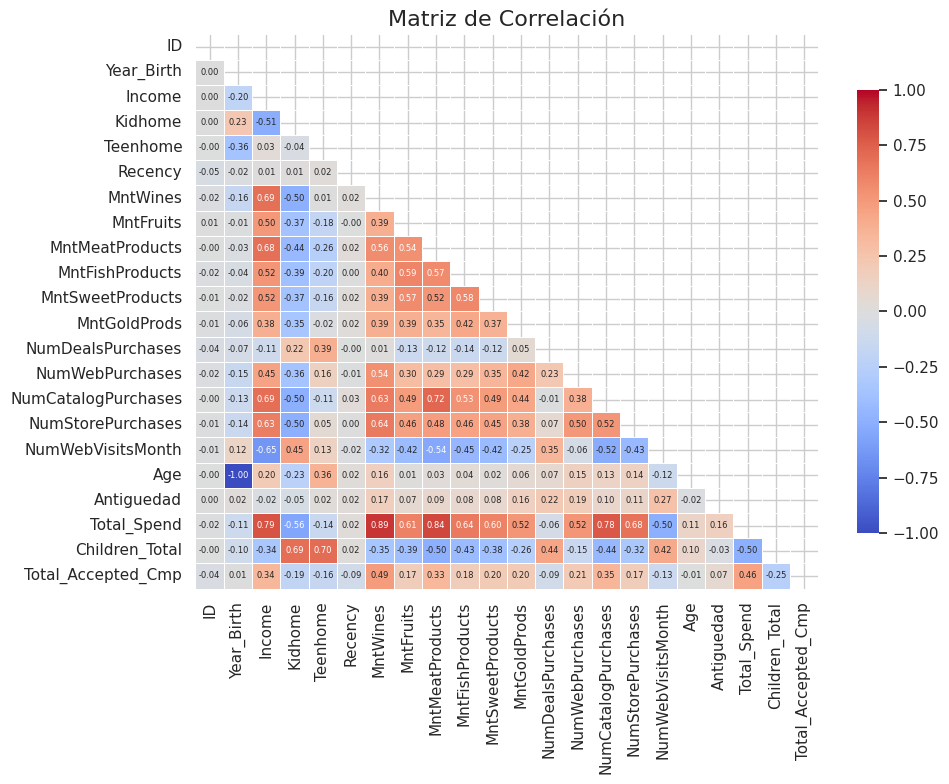

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calcular la matriz de correlación (usando df_clean)
corr_matrix = df_clean.select_dtypes(include=['number']).corr()

# 2. Máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Configurar el gráfico (Tamaño más compacto)
plt.figure(figsize=(10, 8))

# 4. Dibujar Heatmap
# annot_kws={"size": 6} es la clave para hacer los números pequeñitos
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": .8},      # Barra de color ajustada
            annot_kws={"size": 6})        # <--- AQUÍ CAMBIAMOS EL TAMAÑO DE LOS NÚMEROS

plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

#### Pairplot

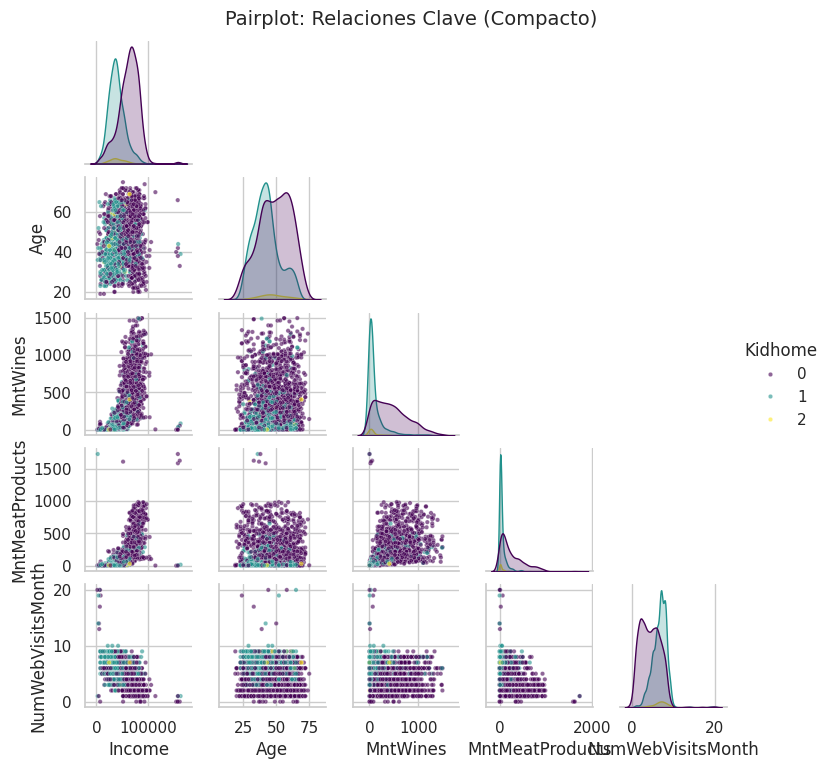

In [45]:
vars_interes = ['Income', 'Age', 'MntWines', 'MntMeatProducts', 'NumWebVisitsMonth']

# Generamos el Pairplot
# height=1.5 -> Hace cada gráfica pequeña (1.5 pulgadas)
# plot_kws={'s': 10} -> Hace los puntos más pequeños (size=10) para que se entienda mejor
sns.pairplot(df_clean[vars_interes + ['Kidhome']],
             hue='Kidhome',
             palette='viridis',
             corner=True,     # Deja solo la mitad inferior (triángulo)
             height=1.5,      # <--- AQUÍ CONTROLAS EL TAMAÑO TOTAL
             plot_kws={'s': 10, 'alpha': 0.6}) # Puntos pequeños y semitransparentes

plt.suptitle("Pairplot: Relaciones Clave (Compacto)", y=1.02, fontsize=14)
plt.show()

#### PCA

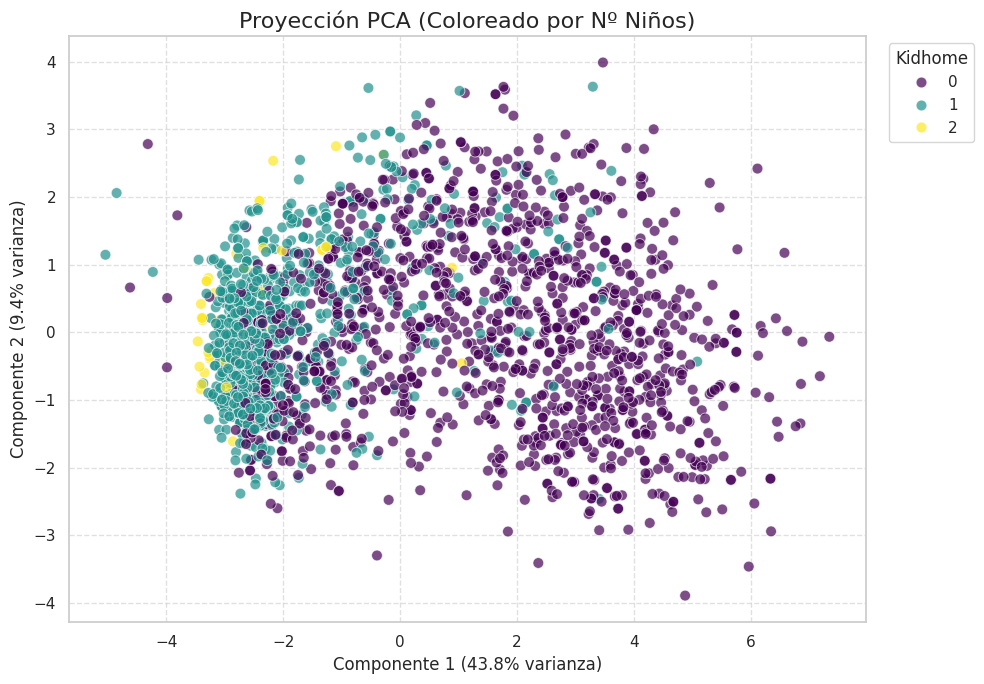

In [46]:
# 1. Preparar los datos
cols_pca = vars_num_perfil + vars_num_productos + vars_num_canales
# Usamos .copy() para asegurar que no modificamos el original
X = df_clean[cols_pca].copy()

# Estandarizar (OBLIGATORIO para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Aplicar PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_scaled)

# Crear un DataFrame con los resultados del PCA
pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# --- PASO CLAVE NUEVO: Añadir la variable de color al dataframe del PCA ---
# Importante usar .values para que coincidan los índices si hubo algún filtrado previo
pca_df['Kidhome'] = df_clean['Kidhome'].values

# 3. Graficar con COLORES DINÁMICOS
plt.figure(figsize=(10, 7))

# CAMBIO AQUÍ: Usamos 'hue' en vez de 'color' fijo
sns.scatterplot(
    x='PC1', y='PC2',
    data=pca_df,
    hue='Kidhome',      # <--- ESTO ES LO QUE DA COLOR
    palette='viridis',  # Paleta de colores bonita
    alpha=0.7,
    s=60                # Tamaño de los puntos un poco más grande
)

# Mejorar títulos y ejes con la varianza explicada
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title(f'Proyección PCA (Coloreado por Nº Niños)', fontsize=16)
plt.xlabel(f'Componente 1 ({var_pc1:.1f}% varianza)')
plt.ylabel(f'Componente 2 ({var_pc2:.1f}% varianza)')
plt.grid(True, linestyle='--', alpha=0.6)

# Mover la leyenda para que no moleste
plt.legend(title='Kidhome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Gráfico 3D

In [47]:
# 1. Preparamos los datos sobre una COPIA del dataframe
# Creamos una variable de 'Gasto Total' que es muy potente para segmentar
df_3d = df_clean.copy()
df_3d['Total_Spend'] = (df_3d['MntWines'] + df_3d['MntFruits'] +
                        df_3d['MntMeatProducts'] + df_3d['MntFishProducts'] +
                        df_3d['MntSweetProducts'] + df_3d['MntGoldProds'])

# 2. Crear el gráfico 3D
# Usamos Income, Gasto Total y Edad como ejes
# Coloreamos por el número de niños en casa (Kidhome)
fig = px.scatter_3d(df_3d,
    x = "Income",       # Eje X: Ingresos
    y = "Total_Spend",  # Eje Y: Gasto Total (Nueva variable)
    z = "Age",          # Eje Z: Edad
    color = 'Kidhome',  # Color según el nº de niños (categórica ordinal)

    # Configuración visual
    opacity = 0.7,      # Un poco transparente para ver a través
    size_max = 10,      # Tamaño de puntos
    width = 1000,       # Ancho del gráfico
    height = 800,       # Alto del gráfico

    # Títulos personalizados para que quede profesional
    title = "Gráfico 3D: Relación entre Ingresos, Gasto Total y Edad (Color por Niños)",
    labels = {
        "Income": "Ingresos Anuales (€)",
        "Total_Spend": "Gasto Total (2 años) (€)",
        "Age": "Edad (Años)",
        "Kidhome": "Niños en casa"
    },
    color_continuous_scale=px.colors.sequential.Viridis # Escala de color bonita
)

# Mejorar la estética de los ejes
fig.update_layout(scene = dict(
                    xaxis_title='INGRESOS',
                    yaxis_title='GASTO TOTAL',
                    zaxis_title='EDAD'),
                  margin=dict(l=0, r=0, b=0, t=40)) # Márgenes ajustados

fig.show()

#### 1.2 Estudio Variables Categóricas

## 2. Procesado inicial de los datos ``(1.5p)``

En este apartado se tiene que elegir las variables que se van a utilizar para los modelos que se usarán posteriormente, se tiene que hacer selección de variables con estudio de correlaciónes ``(0.75p)`` y PCA ``(0.75p)``.

## 3. Clustering ``(5p)``

En este apartado se tienen que utilizar los algoritmos de clustering vistos en clase para hacer la agrupación de los datos.

Se va a pedir que uséis los siguientes modelos:
- Agrupación jerárquica ``(1p)``
- K-means ``(1p)``
- DBSCAN ``(1p)``
- Optics ``(Opcional +0,5p. extras)`` -> _El solamente se aplica si se tiene una nota superior a 5._

La justificación, comparación modelos y explicación del proceso aplicado para hacer el clustering vale ``2p``

## 4. Conclusiones ``(1p)``

Escribid un resumen de lo que se ha hecho y de las decisiones tomadas en cada apartado.